In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)

In [3]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files
# ---------------------------------------------
data_dir = Path("../data")
years = [2020, 2021, 2022, 2023, 2024, 2025]
combined_df = []

for year in years:
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    try:
        xl = pd.ExcelFile(file)
        df = xl.parse("Curtailments")
        df['Year'] = year
        combined_df.append(df)
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

curtailment_df = pd.concat(combined_df, ignore_index=True)

In [4]:
# ---------------------------------------------
# STEP 2: Clean and Enrich Columns
# ---------------------------------------------
# Calculate total curtailed MW per interval
curtailment_df['Total Curtailment (MW)'] = (
    curtailment_df['Solar Curtailment'] + curtailment_df['Wind Curtailment']
)

# Build datetime column (5-minute intervals)
curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Date']) + pd.to_timedelta(
    (curtailment_df['Hour'] - 1) * 60 + (curtailment_df['Interval'] - 1) * 5, unit='m'
)

# Convert MW to MWh
for col in ['Solar Curtailment', 'Wind Curtailment', 'Total Curtailment (MW)']:
    curtailment_df[f"{col} (MWh)"] = curtailment_df[col] * 5 / 60

In [5]:
curtailment_df.head()

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Year,Reason,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh)
0,2020-01-01,9,5,NaN,1.960000,2020,NaN,NaN,2020-01-01 08:20:00,0.163333,NaN,NaN
1,2020-01-01,9,6,NaN,10.430918,2020,NaN,NaN,2020-01-01 08:25:00,0.869243,NaN,NaN
2,2020-01-01,9,10,NaN,1.295686,2020,NaN,NaN,2020-01-01 08:45:00,0.107974,NaN,NaN
3,2020-01-01,9,11,40.030000,153.010799,2020,NaN,193.040799,2020-01-01 08:50:00,12.750900,3.335833,16.086733
4,2020-01-01,9,12,26.946634,161.819285,2020,NaN,188.765920,2020-01-01 08:55:00,13.484940,2.245553,15.730493


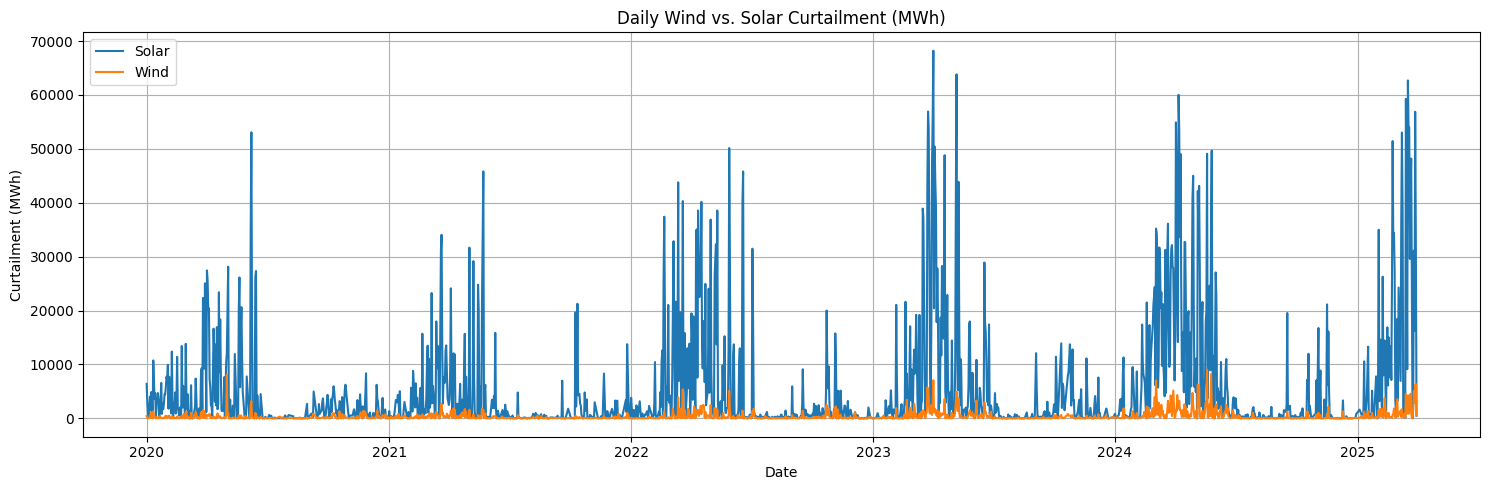

<Figure size 1200x600 with 0 Axes>

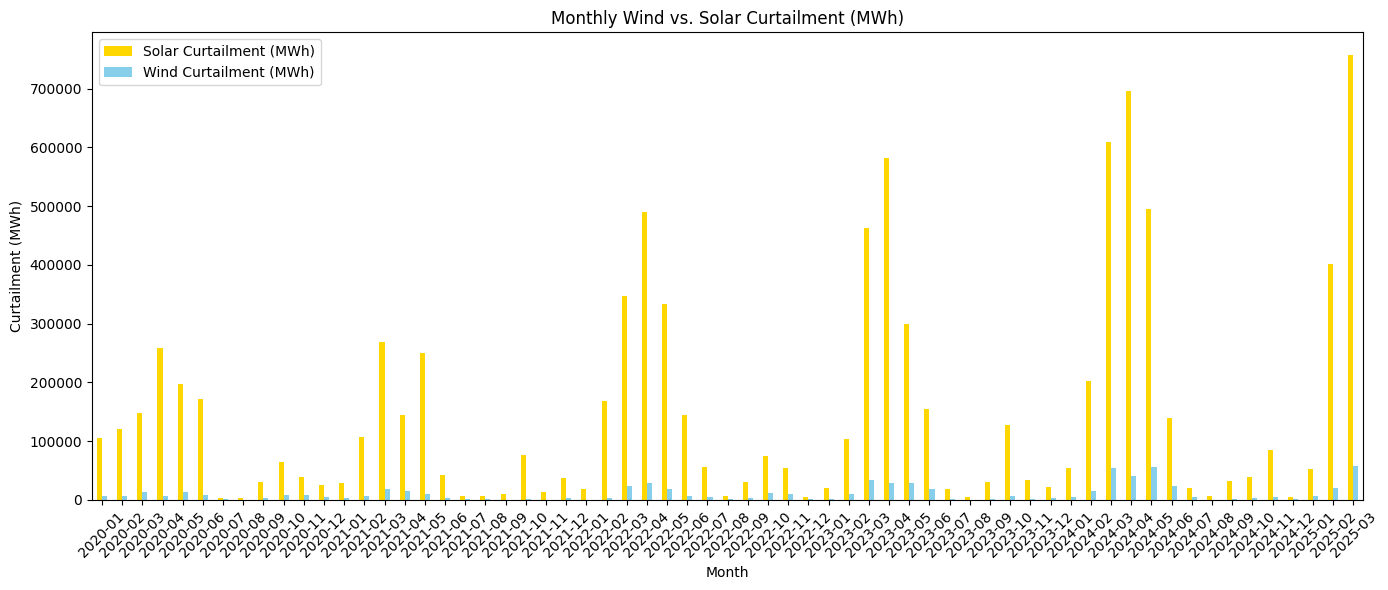

<Figure size 800x500 with 0 Axes>

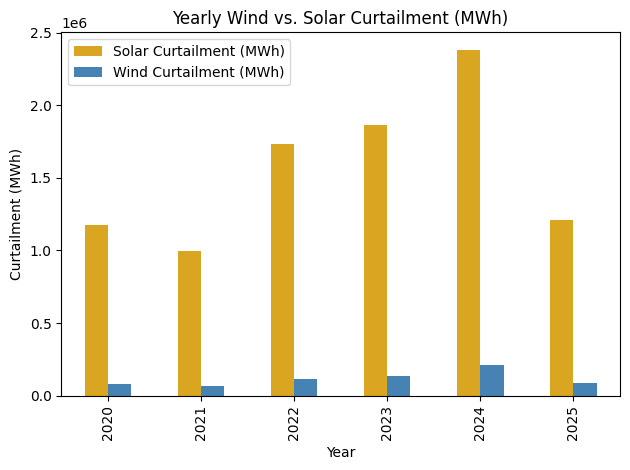

In [6]:
# Create aggregated views of solar and wind curtailment over time
# Drop rows with missing values to ensure clean aggregation
curtailment_df_clean = curtailment_df.copy()
curtailment_df_clean['Date'] = pd.to_datetime(curtailment_df_clean['Date'])
curtailment_df_clean['Month'] = curtailment_df_clean['Datetime'].dt.to_period('M')
curtailment_df_clean = curtailment_df_clean.dropna(subset=['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)'])

# Daily totals
daily_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Date'].dt.date)[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Monthly totals
monthly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Month'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Yearly totals
yearly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Year'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Plot daily curtailment
plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_curtailment, x='Date', y='Solar Curtailment (MWh)', label='Solar')
sns.lineplot(data=daily_curtailment, x='Date', y='Wind Curtailment (MWh)', label='Wind')
plt.title("Daily Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Plot monthly curtailment
plt.figure(figsize=(12, 6))
monthly_curtailment['Month'] = monthly_curtailment['Month'].astype(str)  # for x-axis labels
monthly_curtailment.set_index('Month')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, figsize=(14, 6), color=['gold', 'skyblue']
)
plt.title("Monthly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot yearly curtailment
plt.figure(figsize=(8, 5))
yearly_curtailment.set_index('Year')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, color=['goldenrod', 'steelblue']
)
plt.title("Yearly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Year")
plt.ylabel("Curtailment (MWh)")
plt.tight_layout()
plt.show()


In [7]:
# ---------------------------------------------
# STEP 4: Aggregate by Time and Reason
# ---------------------------------------------
daily = curtailment_df.groupby(['Datetime', 'Reason']).agg({
    'Solar Curtailment (MWh)': 'sum',
    'Wind Curtailment (MWh)': 'sum',
    'Total Curtailment (MW) (MWh)': 'sum'
}).reset_index()
daily['Date'] = daily['Datetime'].dt.date

# Monthly summary
monthly = curtailment_df.groupby(['Month', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# Yearly summary
yearly = curtailment_df.groupby(['Year', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# Save output for next step
# daily.to_csv("../outputs/daily_curtailment_breakdown.csv", index=False)
# monthly.to_csv("../outputs/monthly_curtailment_breakdown.csv", index=False)
# yearly.to_csv("../outputs/yearly_curtailment_breakdown.csv", index=False)

KeyError: 'Month'

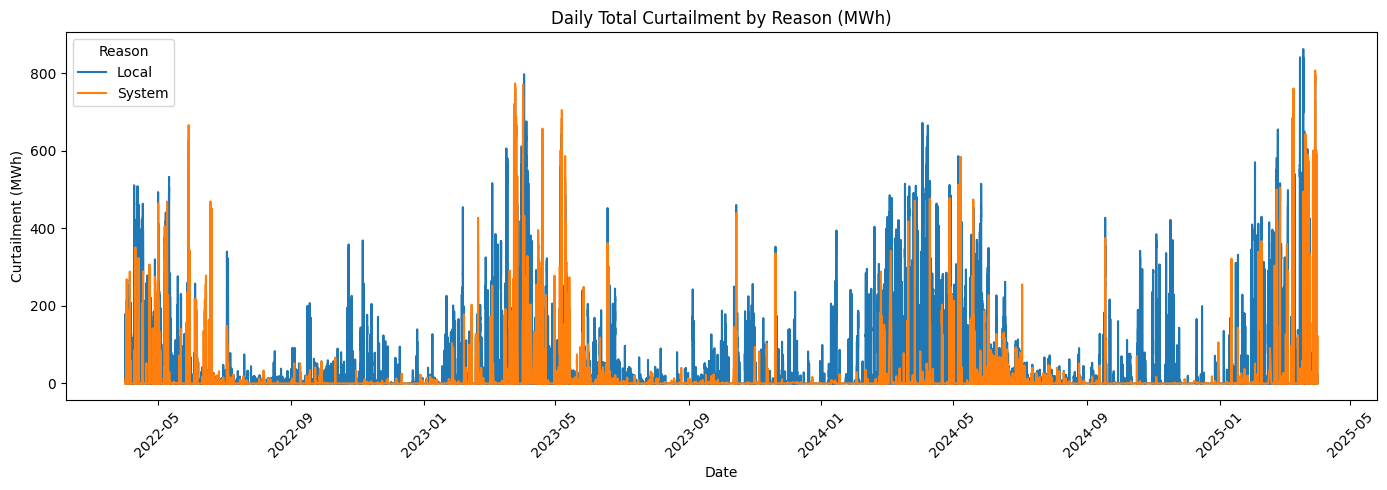

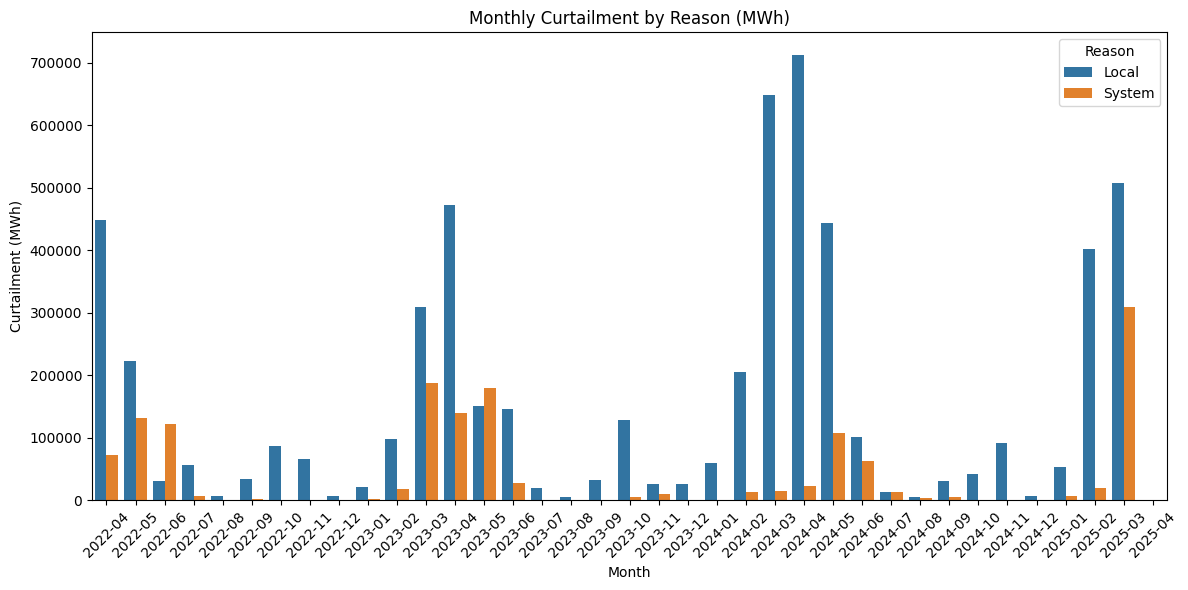

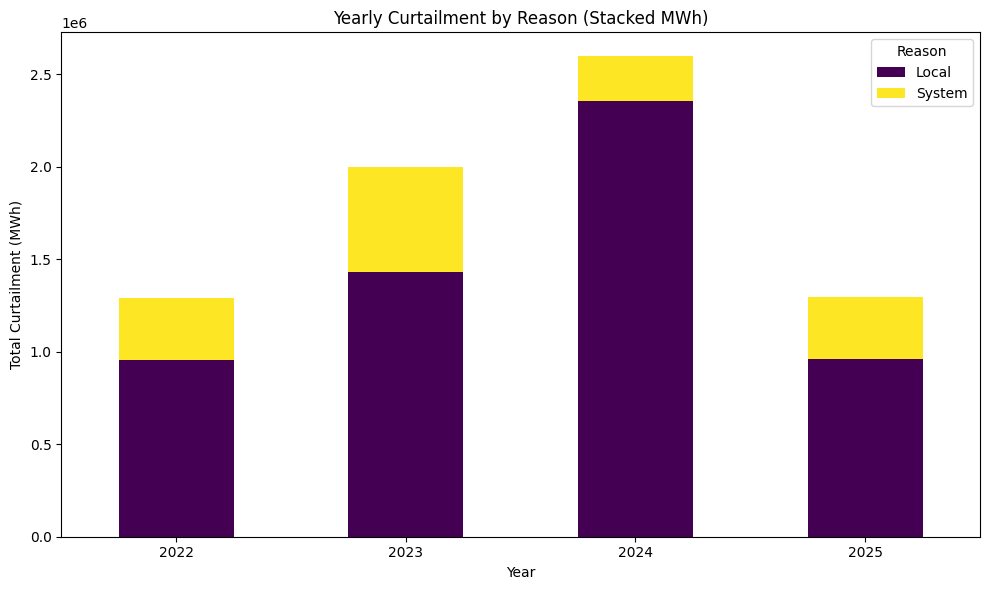

In [9]:
# ---------------------------------------------
# DAILY CURTAILMENT TRENDS
# ---------------------------------------------
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="Datetime", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Daily Total Curtailment by Reason (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# MONTHLY CURTAILMENT COMPARISON
# ---------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly, x="Month", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Monthly Curtailment by Reason (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# YEARLY CURTAILMENT STACKED BAR
# ---------------------------------------------
pivot_yearly = yearly.pivot(index="Year", columns="Reason", values="Total Curtailment (MW) (MWh)")
pivot_yearly.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Yearly Curtailment by Reason (Stacked MWh)")
plt.xlabel("Year")
plt.ylabel("Total Curtailment (MWh)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
yearly_curtailment

,Year,Solar Curtailment (MWh),Wind Curtailment (MWh)
0,2020,1.172475e+06,82326.623818
1,2021,9.958414e+05,68310.158513
2,2022,1.733760e+06,117564.310791
3,2023,1.862576e+06,137096.106369
4,2024,2.384253e+06,212301.104495
5,2025,1.211974e+06,84235.807207


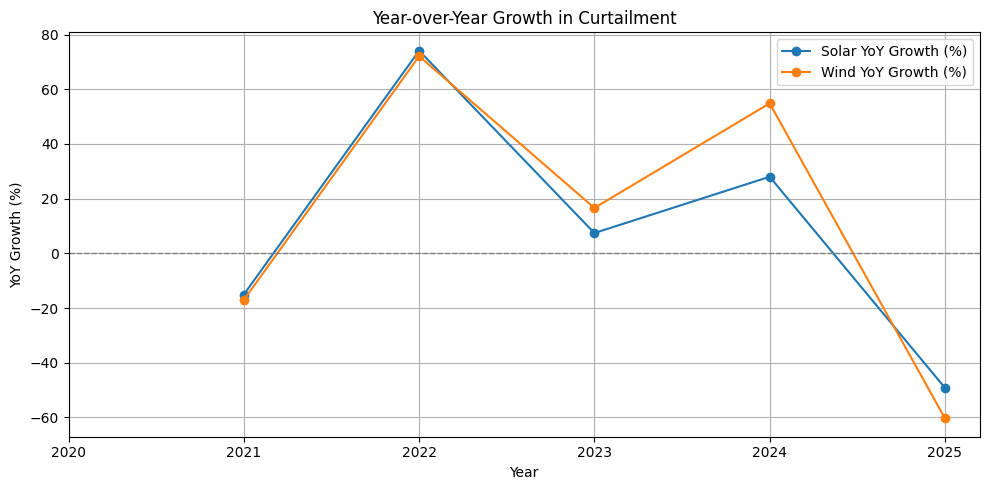

In [8]:
# Compute YoY growth
yearly_curtailment['Solar YoY Growth (%)'] = yearly_curtailment['Solar Curtailment (MWh)'].pct_change() * 100
yearly_curtailment['Wind YoY Growth (%)'] = yearly_curtailment['Wind Curtailment (MWh)'].pct_change() * 100

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Solar YoY Growth (%)'], marker='o', label='Solar YoY Growth (%)')
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Wind YoY Growth (%)'], marker='o', label='Wind YoY Growth (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Fix x-axis ticks
plt.xticks(yearly_curtailment['Year'])

plt.title('Year-over-Year Growth in Curtailment')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

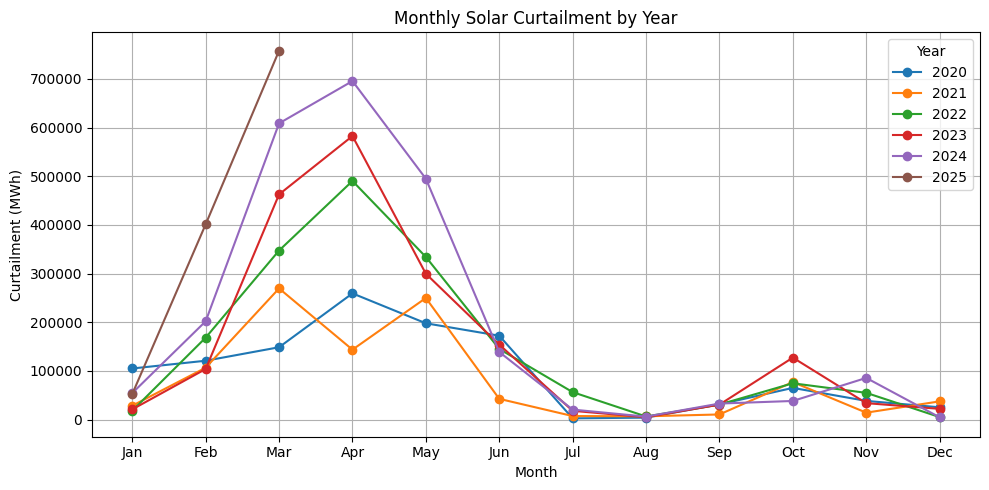

In [9]:
# Assume monthly_curtailment is already loaded
monthly_curtailment['Month'] = pd.to_datetime(monthly_curtailment['Month'])
monthly_curtailment['Year'] = monthly_curtailment['Month'].dt.year
monthly_curtailment['Month_Num'] = monthly_curtailment['Month'].dt.month

# Group by Year and Month_Num for Solar
pivot_solar = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Solar Curtailment (MWh)')

# Plot solar
plt.figure(figsize=(10, 5))
for year in pivot_solar.columns:
    plt.plot(pivot_solar.index, pivot_solar[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Solar Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

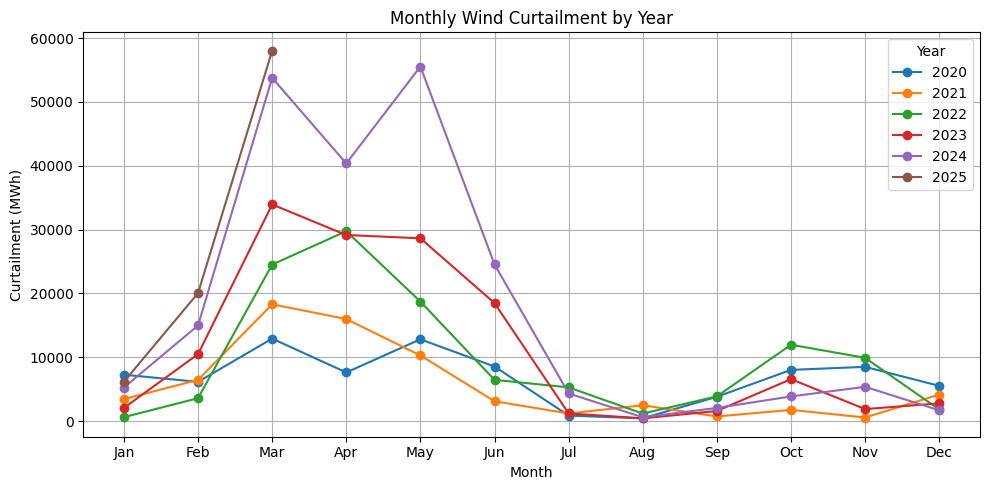

In [10]:
# Repeat for Wind
pivot_wind = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Wind Curtailment (MWh)')

plt.figure(figsize=(10, 5))
for year in pivot_wind.columns:
    plt.plot(pivot_wind.index, pivot_wind[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Wind Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

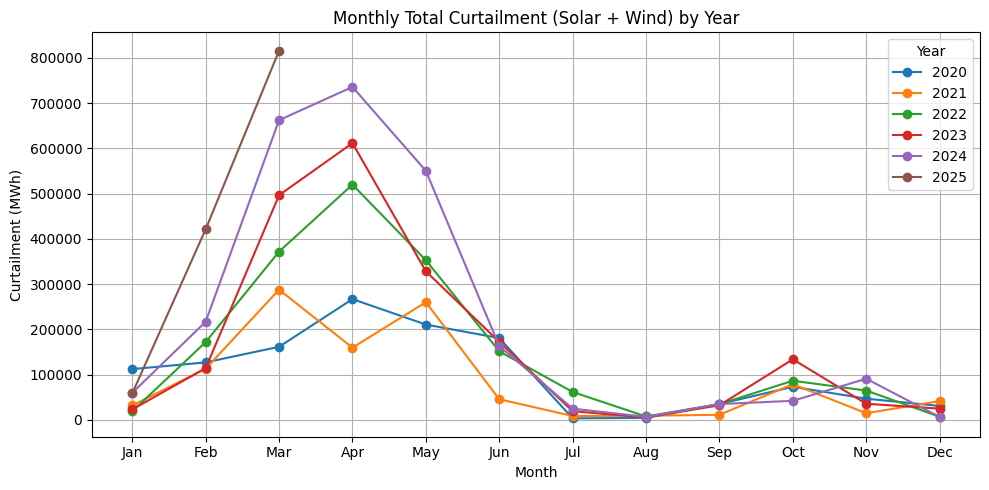

In [11]:
# Add a combined curtailment column
monthly_curtailment['Total Curtailment (MWh)'] = (
    monthly_curtailment['Solar Curtailment (MWh)'] + monthly_curtailment['Wind Curtailment (MWh)']
)

# Pivot for combined curtailment
pivot_total = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Total Curtailment (MWh)')

# Plot total curtailment
plt.figure(figsize=(10, 5))
for year in pivot_total.columns:
    plt.plot(pivot_total.index, pivot_total[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Total Curtailment (Solar + Wind) by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

computing the mean curtailment at each hour of the day.

For example, “How much solar curtailment happens on average at 12pm in April?”

The result shows temporal patterns, but not total daily volume.

If you sum those hourly values, the total is much smaller (e.g., ~1,700 MWh/day), because it smooths over intra-hour spikes and sparse curtailment days.

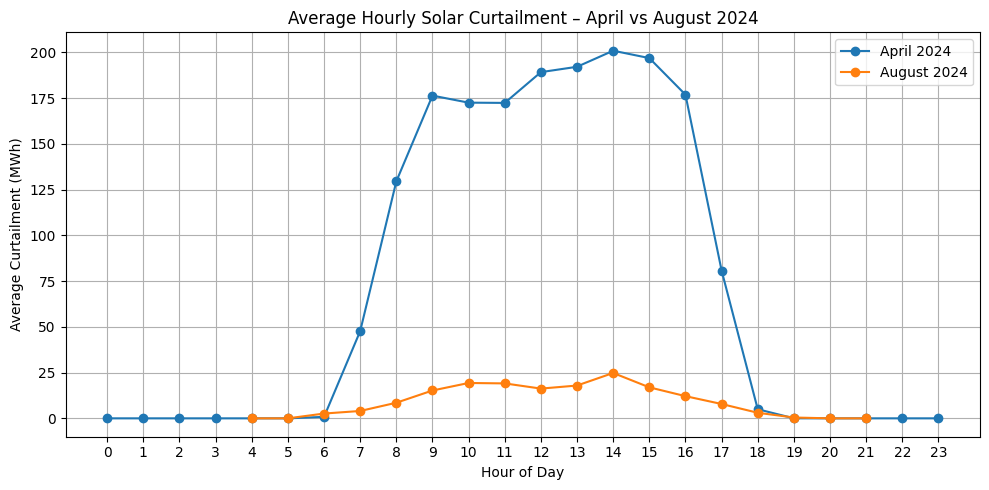

In [12]:
# Filter April 2024 data
#curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Datetime'])
curtailment_df['Datetime'] = curtailment_df['Datetime'] - pd.Timedelta(hours=7)
# Filter April 2024
df_april = curtailment_df[
    (curtailment_df['Datetime'].dt.month == 4) & (curtailment_df['Datetime'].dt.year == 2024)
].copy()

# Filter August 2024
df_august = curtailment_df[
    (curtailment_df['Datetime'].dt.month == 8) & (curtailment_df['Datetime'].dt.year == 2024)
].copy()

# Extract hour and fill NaNs
for df in [df_april, df_august]:
    df['Hour'] = df['Datetime'].dt.hour
    df['Solar Curtailment (MWh)'] = df['Solar Curtailment (MWh)'].fillna(0)

# Group by hour and compute averages
avg_april = df_april.groupby('Hour')['Solar Curtailment (MWh)'].mean()
avg_august = df_august.groupby('Hour')['Solar Curtailment (MWh)'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_april.index, avg_april.values, marker='o', label='April 2024')
plt.plot(avg_august.index, avg_august.values, marker='o', label='August 2024')
plt.title('Average Hourly Solar Curtailment – April vs August 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Average Curtailment (MWh)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [33]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files (Production sheet)
# ---------------------------------------------
data_dir = Path("../data")
years = [2020, 2021, 2022, 2023, 2024, 2025]
production_combined = []

for year in years:
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    try:
        xl = pd.ExcelFile(file)
        df_prod = xl.parse("Production")
        df_prod['Year'] = year
        production_combined.append(df_prod)
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

production_df = pd.concat(production_combined, ignore_index=True)

# Ensure 'Date' is parsed as datetime
production_df['Date'] = pd.to_datetime(production_df['Date'])

/var/folders/1s/l7126wmd6674c5hlyz6rwhpc0000gp/T/ipykernel_29457/1466999990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_april['Date'] = df_april['Datetime'].dt.date


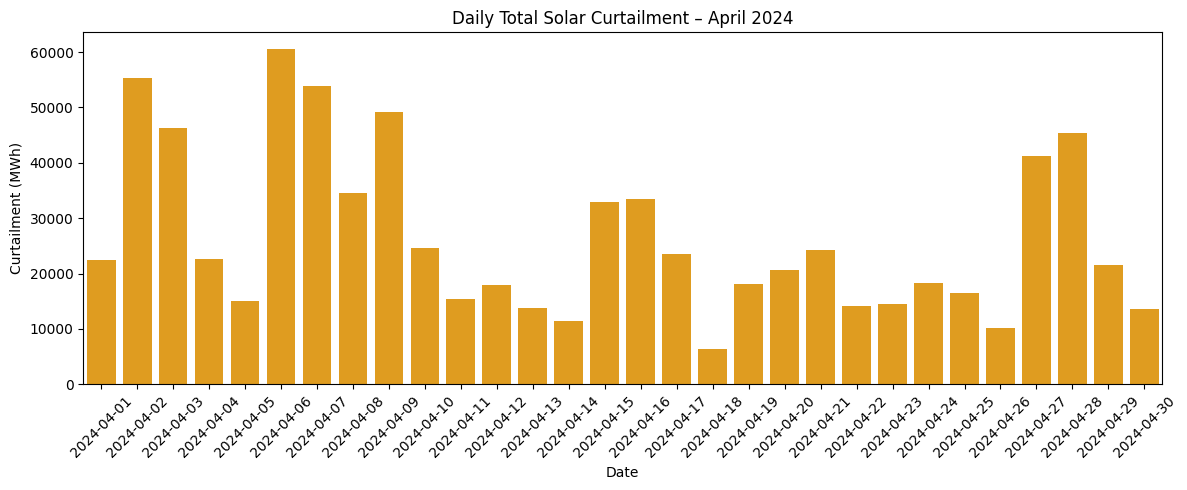

In [14]:
# Daily total solar curtailment
df_april['Date'] = df_april['Datetime'].dt.date
daily_totals = df_april.groupby('Date')['Solar Curtailment (MWh)'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=daily_totals, x='Date', y='Solar Curtailment (MWh)', color='orange')
plt.xticks(rotation=45)
plt.title("Daily Total Solar Curtailment – April 2024")
plt.ylabel("Curtailment (MWh)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

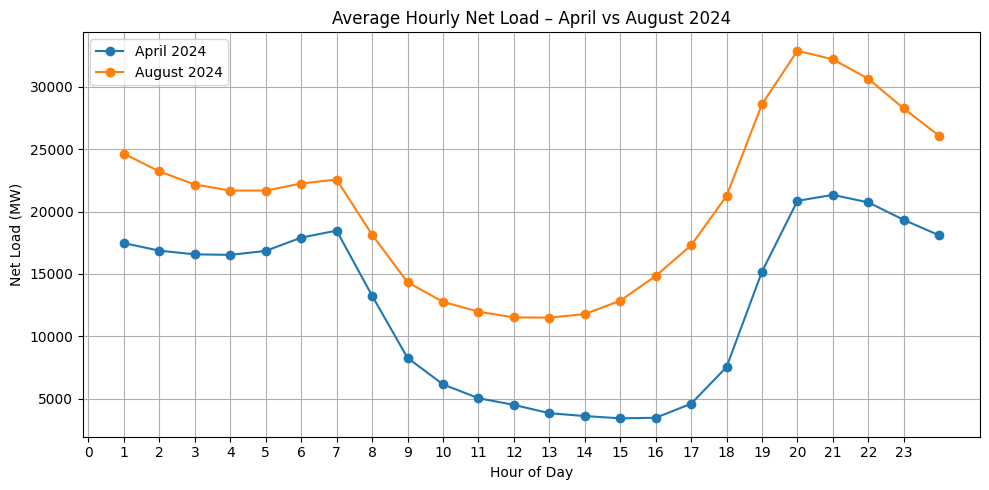

In [42]:
# Ensure Hour is integer and Date is datetime
production_df['Hour'] = production_df['Hour'].astype(int)
#production_df['Date'] = pd.to_datetime(production_df['Date'])

# Filter April 2024
df_april = production_df[
    (production_df['Date'].dt.month == 4) & (production_df['Date'].dt.year == 2024)
].copy()

# Filter August 2024
df_august = production_df[
    (production_df['Date'].dt.month == 8) & (production_df['Date'].dt.year == 2024)
].copy()

# Compute average hourly net load
avg_april = df_april.groupby('Hour')['Net Load'].mean()
avg_august = df_august.groupby('Hour')['Net Load'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_april.index, avg_april.values, marker='o', label='April 2024')
plt.plot(avg_august.index, avg_august.values, marker='o', label='August 2024')
plt.title('Average Hourly Net Load – April vs August 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Net Load (MW)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


1. Clear temporal patterns
Curtailment spikes midday → aligns with solar generation peak.
Spring months (especially April) show high average curtailment → matches real-world CAISO reports.
These point to strong seasonality + diurnal structure.

2. Year-over-year growth trend
Total curtailed MWh is increasing, especially for solar.
There’s a structural oversupply problem, not just a weather-driven one.

3. Curtailment timing aligns with net load dips, Midday → High Solar Output → Net Load Drops → Oversupply → Curtailment
Solar generation depresses net load during certain hours, creating curtailment pressure.

Curtailment is a forecastable quantity influenced by:
Time features (hour, month, weekday)

Supply capacity (installed solar/wind MW over time)

Demand (total load, net load trends)

Storage deployment (batteries reduce curtailment)

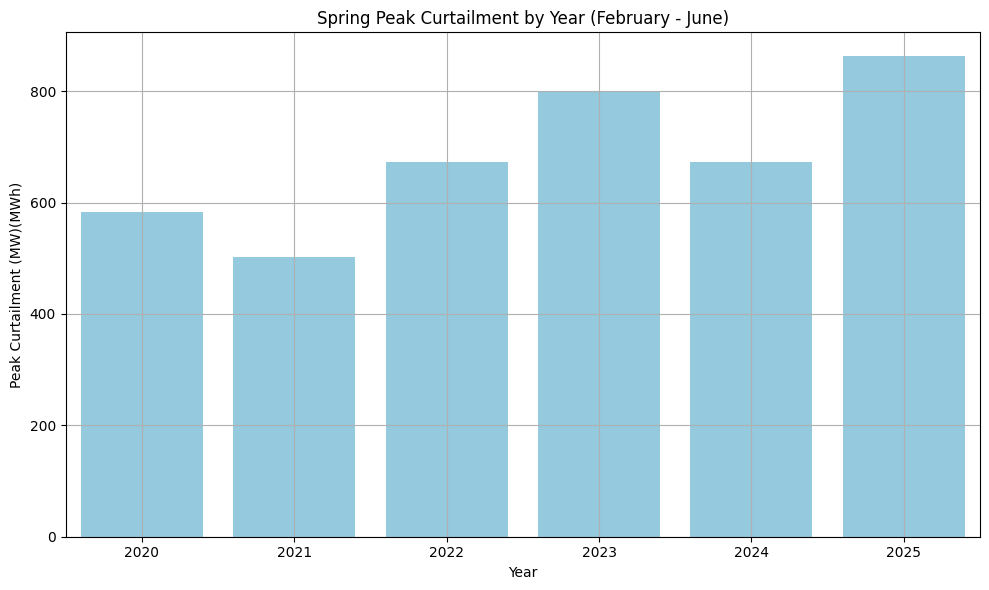

In [50]:
# Define spring months for analysis (March, April, May)
spring_months = [2, 3, 4, 5, 6]
spring_df = curtailment_df[curtailment_df['Month_Num'].isin(spring_months)]

# Group by year and calculate metrics
spring_summary = spring_df.groupby('Year')['Total Curtailment (MW) (MWh)'].agg(
    Spring_Total_Curtailment_MWh='sum',
    Spring_Average_Daily_Curtailment_MWh='mean',
    Spring_Peak_Curtailment_MWh='max'
).reset_index()

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Plotting peak curtailment during spring for each year
plt.figure(figsize=(10, 6))
sns.barplot(data=spring_summary, x='Year', y='Spring_Peak_Curtailment_MWh', color='skyblue')
plt.title("Spring Peak Curtailment by Year (February - June)")
plt.ylabel("Peak Curtailment (MW)(MWh)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
curtailment_df.head()

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Year,Reason,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh)
0,2020-01-01,9,5,NaN,1.960000,2020,NaN,NaN,2020-01-01 01:20:00,0.163333,NaN,NaN
1,2020-01-01,9,6,NaN,10.430918,2020,NaN,NaN,2020-01-01 01:25:00,0.869243,NaN,NaN
2,2020-01-01,9,10,NaN,1.295686,2020,NaN,NaN,2020-01-01 01:45:00,0.107974,NaN,NaN
3,2020-01-01,9,11,40.030000,153.010799,2020,NaN,193.040799,2020-01-01 01:50:00,12.750900,3.335833,16.086733
4,2020-01-01,9,12,26.946634,161.819285,2020,NaN,188.765920,2020-01-01 01:55:00,13.484940,2.245553,15.730493


In [47]:
curtailment_df['Month_Num'] = curtailment_df['Date'].dt.month

In [48]:
# Filter non-peak season data
non_peak_df = curtailment_df[~curtailment_df['Month_Num'].isin(spring_months)]

# Compute average daily curtailment outside of peak season
avg_non_peak_curtailment = non_peak_df['Total Curtailment (MW) (MWh)'].mean()

avg_non_peak_curtailment

np.float64(49.48941488392218)

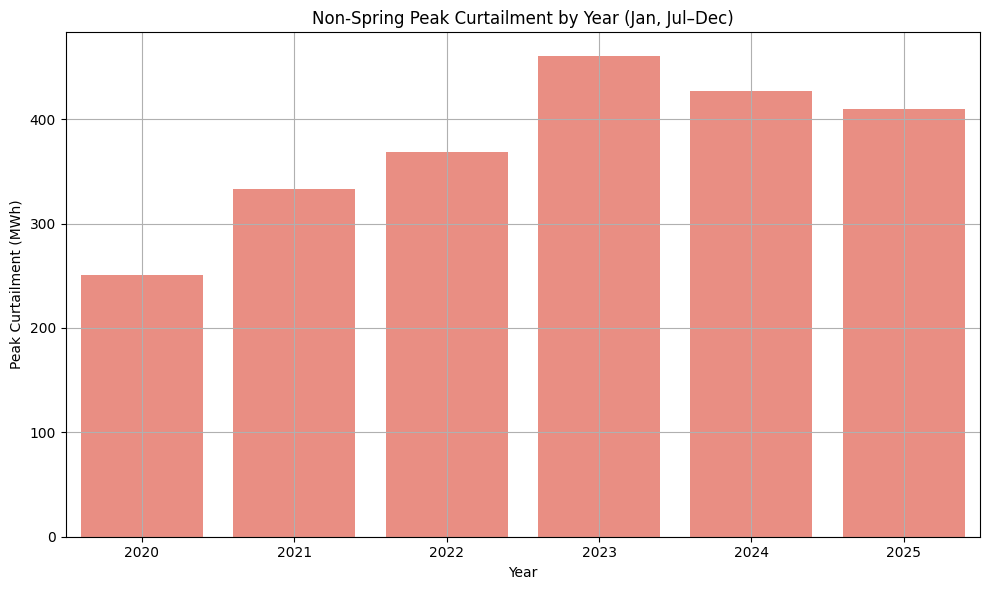

In [49]:
# Group by year and calculate metrics
non_spring_summary = non_peak_df.groupby('Year')['Total Curtailment (MW) (MWh)'].agg(
    NonSpring_Total_Curtailment_MWh='sum',
    NonSpring_Average_Daily_Curtailment_MWh='mean',
    NonSpring_Peak_Curtailment_MWh='max'
).reset_index()

# Plotting peak curtailment during non-spring for each year
plt.figure(figsize=(10, 6))
sns.barplot(data=non_spring_summary, x='Year', y='NonSpring_Peak_Curtailment_MWh', color='salmon')
plt.title("Non-Spring Peak Curtailment by Year (Jan, Jul–Dec)")
plt.ylabel("Peak Curtailment (MWh)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

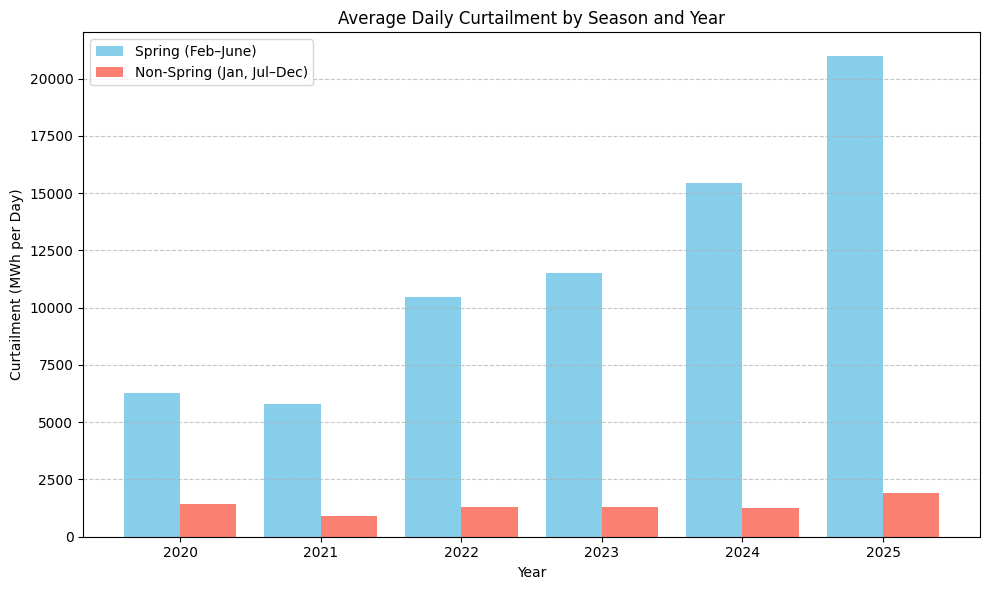

In [51]:
# Step 1: Group by Date to get daily totals
daily_totals = curtailment_df.groupby(['Date']).agg(
    Daily_Curtailment_MWh=('Total Curtailment (MW) (MWh)', 'sum')
).reset_index()

# Extract Year and Month from Date
daily_totals['Year'] = pd.to_datetime(daily_totals['Date']).dt.year
daily_totals['Month_Num'] = pd.to_datetime(daily_totals['Date']).dt.month

# Step 2: Define Spring vs Non-Spring
spring_months = [2, 3, 4, 5, 6]
spring_df = daily_totals[daily_totals['Month_Num'].isin(spring_months)]
non_spring_df = daily_totals[~daily_totals['Month_Num'].isin(spring_months)]

# Step 3: Group and summarize
spring_summary = spring_df.groupby('Year')['Daily_Curtailment_MWh'].mean().reset_index(name='Spring_Daily_Avg_MWh')
non_spring_summary = non_spring_df.groupby('Year')['Daily_Curtailment_MWh'].mean().reset_index(name='NonSpring_Daily_Avg_MWh')

# Step 4: Merge and Plot
season_comparison = pd.merge(spring_summary, non_spring_summary, on='Year')

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = range(len(season_comparison))

plt.bar(x, season_comparison['Spring_Daily_Avg_MWh'], width=bar_width, label='Spring (Feb–June)', color='skyblue')
plt.bar([i + bar_width for i in x], season_comparison['NonSpring_Daily_Avg_MWh'], width=bar_width, label='Non-Spring (Jan, Jul–Dec)', color='salmon')

plt.xticks([i + bar_width / 2 for i in x], season_comparison['Year'].astype(str))
plt.title("Average Daily Curtailment by Season and Year")
plt.ylabel("Curtailment (MWh per Day)")
plt.xlabel("Year")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
curtailment_df

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Year,Reason,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh)
0,2020-01-01 00:00:00,9,5,NaN,1.960000,2020,NaN,NaN,2020-01-01 01:20:00,0.163333,NaN,NaN
1,2020-01-01 00:00:00,9,6,NaN,10.430918,2020,NaN,NaN,2020-01-01 01:25:00,0.869243,NaN,NaN
2,2020-01-01 00:00:00,9,10,NaN,1.295686,2020,NaN,NaN,2020-01-01 01:45:00,0.107974,NaN,NaN
3,2020-01-01 00:00:00,9,11,40.030000,153.010799,2020,NaN,193.040799,2020-01-01 01:50:00,12.750900,3.335833,16.086733
4,2020-01-01 00:00:00,9,12,26.946634,161.819285,2020,NaN,188.765920,2020-01-01 01:55:00,13.484940,2.245553,15.730493
...,...,...,...,...,...,...,...,...,...,...,...,...
266404,2025-03-31 07:00:00,18,3,NaN,8.289998,2025,System,NaN,2025-03-31 17:10:00,0.690833,NaN,NaN
266405,2025-03-31 07:00:00,18,4,NaN,5.191092,2025,System,NaN,2025-03-31 17:15:00,0.432591,NaN,NaN
266406,2025-03-31 07:00:00,18,8,NaN,7.423253,2025,Local,NaN,2025-03-31 17:35:00,0.618604,NaN,NaN
266407,2025-03-31 07:00:00,18,9,NaN,7.619995,2025,Local,NaN,2025-03-31 17:40:00,0.635000,NaN,NaN


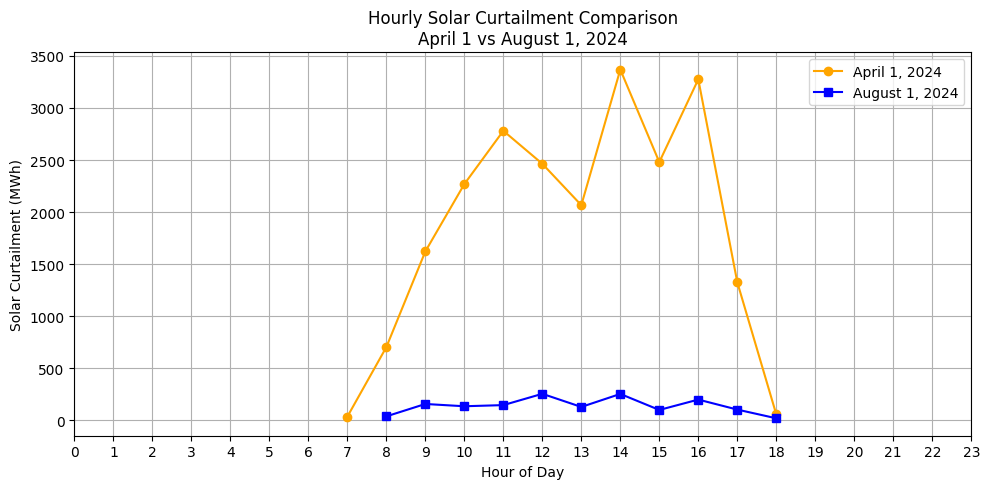

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# If not already in datetime format
curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Datetime'])

# Extract date and hour for grouping
curtailment_df['Date'] = curtailment_df['Datetime'].dt.date
curtailment_df['Hour'] = curtailment_df['Datetime'].dt.hour

# Fill NaNs in Solar Curtailment column
curtailment_df['Solar Curtailment (MWh)'] = curtailment_df['Solar Curtailment (MWh)'].fillna(0)

# Filter for April 1, 2024
apr1_df = curtailment_df[curtailment_df['Date'] == pd.to_datetime("2024-04-01").date()]
apr1_hourly = apr1_df.groupby('Hour')['Solar Curtailment (MWh)'].sum()

# Filter for August 1, 2024
aug1_df = curtailment_df[curtailment_df['Date'] == pd.to_datetime("2024-08-01").date()]
aug1_hourly = aug1_df.groupby('Hour')['Solar Curtailment (MWh)'].sum()

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(apr1_hourly.index, apr1_hourly.values, marker='o', label='April 1, 2024', color='orange')
plt.plot(aug1_hourly.index, aug1_hourly.values, marker='s', label='August 1, 2024', color='blue')
plt.title("Hourly Solar Curtailment Comparison\nApril 1 vs August 1, 2024")
plt.xlabel("Hour of Day")
plt.ylabel("Solar Curtailment (MWh)")
plt.grid(True)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()